In [1]:
#%%
from pycaret.classification import *
from pycaret.classification import ClassificationExperiment
import shap
import pandas as pd
import numpy as np  


In [2]:
#%%
# Load prepred data

data = pd.read_csv("../data/processed/credit_risk_prepared.csv")
data.reset_index(inplace=True, drop=True)
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [3]:
test_size, folds = .2, 10

model = setup(data = data, target = 'loan_status'
              , session_id=123
              ,train_size=(1-test_size)
              ,fold=folds
              ,) 


,Description,Value
0,Session id,123
1,Target,loan_status
2,Target type,Binary
3,Original data shape,"(28632, 12)"
4,Transformed data shape,"(28632, 26)"
5,Transformed train set shape,"(22905, 26)"
6,Transformed test set shape,"(5727, 26)"
7,Numeric features,7
8,Categorical features,4
9,Preprocess,True


In [5]:
# Print the list of available models
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [4]:
best = compare_models(include = ['catboost','lda','lr','rf','et']) #'lightgbm','

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.9375,0.9452,0.7299,0.9755,0.8348,0.7973,0.8102,1.0660
rf,Random Forest Classifier,0.9345,0.9330,0.7184,0.9720,0.8260,0.7868,0.8005,0.1270
et,Extra Trees Classifier,0.9219,0.9150,0.6873,0.9347,0.7917,0.7450,0.7587,0.1300
lda,Linear Discriminant Analysis,0.8656,0.8683,0.5888,0.7378,0.6548,0.5727,0.5784,0.1140
lr,Logistic Regression,0.8524,0.8525,0.4695,0.7564,0.5791,0.4956,0.5164,0.1890


In [ ]:
model_evaluation = evaluate_model(best)

model_evaluation

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

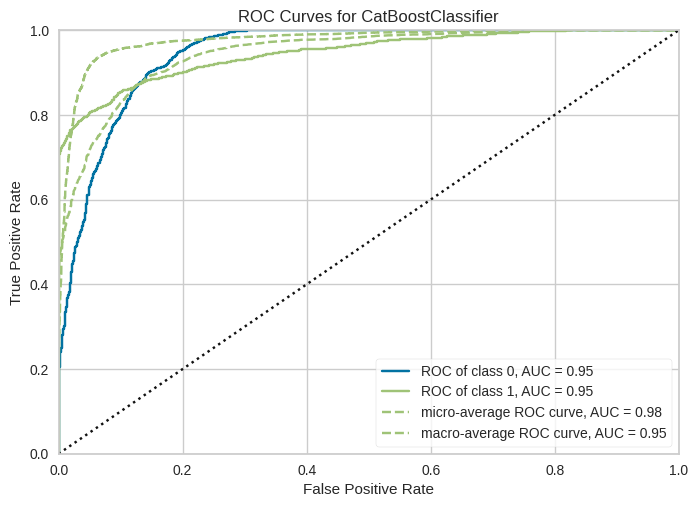

In [ ]:
# functional API
plot_model(best, plot = 'auc')



In [63]:
# Let's make predictions
pred_holdout = predict_model(best)

pred_holdout.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,CatBoost Classifier,0.9361,0.9458,0.7164,0.9845,0.8293,0.7912,0.8063


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status,prediction_label,prediction_score
23594,27,44000,RENT,2.0,MEDICAL,B,15000,11.480000,0.34,N,5,1,1,0.9981
21935,34,78301,MORTGAGE,6.0,DEBTCONSOLIDATION,A,17000,6.620000,0.22,N,9,0,0,0.9847
13462,25,130000,MORTGAGE,0.0,HOMEIMPROVEMENT,A,6325,6.540000,0.05,N,3,0,0,0.9874
16102,34,138000,RENT,0.0,HOMEIMPROVEMENT,E,21000,18.790001,0.15,N,10,1,1,0.9326
23232,27,100000,MORTGAGE,10.0,MEDICAL,B,12000,9.960000,0.12,N,10,0,0,0.9768


In [95]:
# save pipeline
final_model = finalize_model(best)
save_model(best, '../models/model')


Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['person_age', 'person_income',
                                              'person_emp_length', 'loan_amnt',
                                              'loan_int_rate',
                                              'loan_percent_income',
                                              'cb_person_cred_hist_length'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=n...
                                     include=['person_home_ownership',
                      

#### Model Explaination

In [96]:
saved_model = load_model('../models/model')
saved_model

Transformation Pipeline and Model Successfully Loaded


Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['person_age', 'person_income',
                                             'person_emp_length', 'loan_amnt',
                                             'loan_int_rate',
                                             'loan_percent_income',
                                             'cb_person_cred_hist_length'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missi...
                                    include=['person_home_ownership',
                                             'loan_intent', 'loan_grade'],
                                    transformer=OneHotEncoder(cols=['person_home_ownership',
                                                                    'loan_intent',
                                                                    'loan_grade'],
                                                              drop_invariant=False,
                                                              handle_missing='return_nan',
                                                              handle_unknown='value',
                                                              return_df=True,
                                                              use_cat_names=True,
                                                              verbose=0))),
                ('trained_model',
                 CatBoostClassifier(border_count=254, random_state=123, task_type='CPU', verbose=False))],
         verbose=False)

In [8]:
# Transform data set  to get explainations
from pycaret.classification import get_config
prep_pipe = get_config('pipeline') # Or 'prep_pipe' in some versions
transformed_new_data = prep_pipe.transform(data)
transformed_new_data

,person_age,person_income,person_home_ownership_RENT,person_home_ownership_MORTGAGE,person_home_ownership_OWN,person_home_ownership_OTHER,person_emp_length,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_PERSONAL,...,loan_grade_C,loan_grade_E,loan_grade_F,loan_grade_G,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21.0,9600.0,0.0,0.0,1.0,0.0,5.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1000.0,11.14,0,0.10,0.0,2.0
1,25.0,9600.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,5500.0,12.87,1,0.57,0.0,3.0
2,23.0,65500.0,1.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,35000.0,15.23,1,0.53,0.0,2.0
3,24.0,54400.0,1.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,35000.0,14.27,1,0.55,1.0,4.0
4,21.0,9900.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2500.0,7.14,1,0.25,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28627,57.0,53000.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,5800.0,13.16,0,0.11,0.0,30.0
28628,54.0,120000.0,0.0,1.0,0.0,0.0,4.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,17625.0,7.49,0,0.15,0.0,19.0
28629,65.0,76000.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,35000.0,10.99,1,0.46,0.0,28.0
28630,56.0,150000.0,0.0,1.0,0.0,0.0,5.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,15000.0,11.48,0,0.10,0.0,26.0


In [54]:
explainer = shap.TreeExplainer(saved_model.named_steps["trained_model"])
shap_values = explainer.shap_values(transformed_new_data)

In [10]:
shap.initjs()
idx = 4
shap.force_plot(explainer.expected_value, shap_values[idx,:], transformed_new_data.iloc[idx,:])

In [44]:
# visualize a sample all at once in an interactive plot
new_data_sample = transformed_new_data.sample(1000,random_state=123)

shap.force_plot(explainer.expected_value, shap_values[new_data_sample.index], new_data_sample)

shap.explainers._tree.TreeExplainer

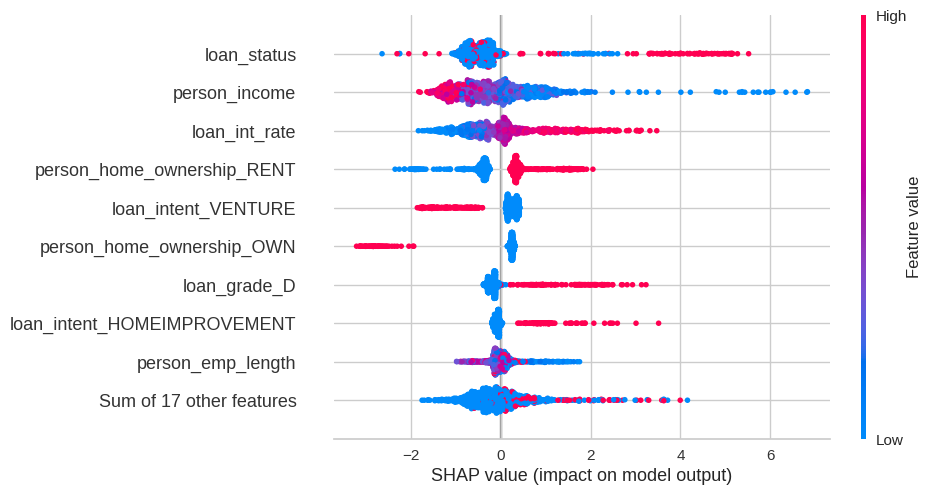

In [ ]:
# summarize the effects of all the features
# Plot below sorts features by the sum of SHAP value magnitudes over all samples
# using SHAP values to show the distribution of the impacts each feature has on the model output.
# The color represents the feature value (red high, blue low)   

# Now the beeswarm plot will work
shap.plots.beeswarm(explainer(new_data_sample ))

In [94]:
import dvc.api

params = dvc.api.params_show('../dvc.yaml')
params['stages']['train']['params']

['train.seed']